# 6. Interpolación

## Librerias

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

from skimage import exposure
import numpy as np

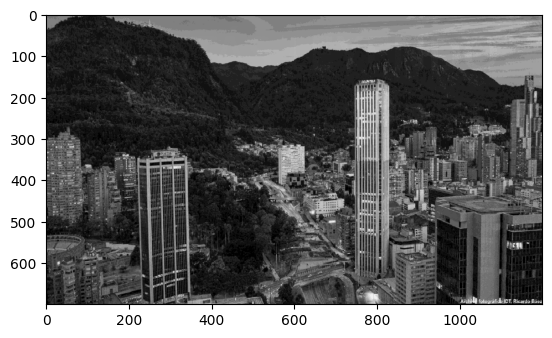

In [5]:
img = cv2.imread('../img/ImagenBogota.png')

plt.imshow(img)
plt.show()

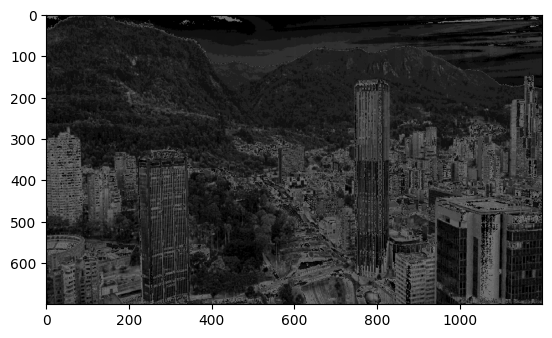

In [6]:
mask = np.full(img.shape, 127,dtype=np.uint8)

masked_img = cv2.bitwise_and(img,mask)

plt.imshow(masked_img)
plt.show()

In [7]:
def image_quantization(imagen, k):
    # plane = np.full(imagen.shape, 255-2 ** k, np.uint8)
    plane = np.full(imagen.shape, 2 ** k, np.uint8)
    # print(f'value={255-2 ** k}')
    print(f'value={2 ** k}')
    return cv2.bitwise_and(plane, imagen)

value=16


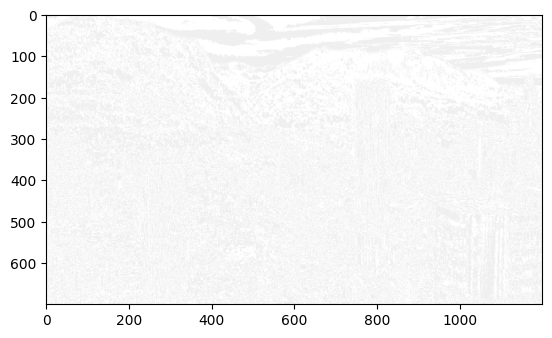

In [8]:
plt.imshow( cv2.bitwise_not(image_quantization(img, 4)) )


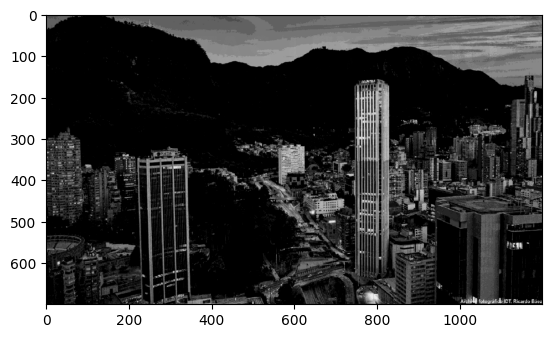

In [9]:
rescaled_img = exposure.rescale_intensity(img, in_range=(50,255), out_range=(0,255))
rescaled_img = rescaled_img.astype(np.uint8)
plt.imshow(rescaled_img)
plt.show()

In [10]:
from ipywidgets import interact

def plot_function(a=1.0, b=0.0):
    x = np.linspace(0, 10, 400)
    y = a * np.sin(x) + b

    plt.figure(figsize=(6, 4))
    plt.plot(x, y)
    plt.ylim(-3, 3)
    plt.grid(True)
    plt.show()

def plot_function(k, inv):
    if inv:
      res_img = cv2.bitwise_not(img)
    else:
       res_img = img
        
    res_img = image_quantization(res_img, k)

    lut_inverse = np.zeros((256, 1), dtype=np.uint8)
    for i in range(1,256):
        lut_inverse[i] = 255


    res_img = cv2.LUT(res_img , lut_inverse )

    plt.imshow( res_img)



interact(
    plot_function,
    k=(0,7,1),
    inv=False
    # a=(-2.0, 2.0, 0.1),
    # b=(-2.0, 2.0, 0.1)
)


interactive(children=(IntSlider(value=3, description='k', max=7), Checkbox(value=False, description='inv'), Ou…

<function __main__.plot_function(k, inv)>

In [11]:
def get_img(k):
        
  res_img = image_quantization(img, k)

  lut_inverse = np.zeros((256, 1), dtype=np.uint8)
  for i in range(1,256):
      lut_inverse[i] = 255


  res_img = cv2.LUT(res_img , lut_inverse )

  return res_img

value=1
value=2
value=4
value=8


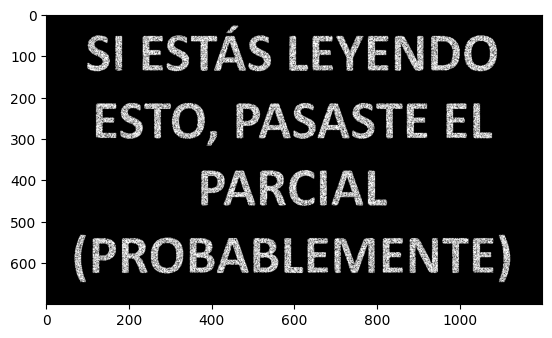

In [12]:


msg_img = np.full(img.shape,0,dtype=np.uint8)

for i in range(0,4):
  partial_msg_img = get_img(i)

  msg_img = cv2.bitwise_or(msg_img, partial_msg_img)

plt.imshow(msg_img)
plt.show()

In [13]:
t_img = cv2.imread('../img/ImagenBogota.png', cv2.IMREAD_GRAYSCALE)

def plot_function(k):
        
    res_img = image_quantization(t_img, k)
    _, res_img = cv2.threshold(res_img, 0, 255, cv2.THRESH_BINARY)
    plt.imshow( res_img,cmap='gray')



interact(
    plot_function,
    k=(0,7,1),
    # a=(-2.0, 2.0, 0.1),
    # b=(-2.0, 2.0, 0.1)
)

interactive(children=(IntSlider(value=3, description='k', max=7), Output()), _dom_classes=('widget-interact',)…

<function __main__.plot_function(k)>